<a href="https://colab.research.google.com/github/axelvazquezp/Analysis-ConnectaTel/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

El objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello usaremos tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Se va a **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [5]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [7]:
# cargar archivos
plans = pd.read_csv('plans.csv')
users = pd.read_csv('users_latam.csv')
usage = pd.read_csv('usage.csv')

In [10]:
# mostrar las primeras 5 filas de plans
plans.head()


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [11]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [12]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.


In [13]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [15]:
# inspección de plans con .info() **resumen completo** de columnas, tipos de datos y valores no nulos
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [16]:
# inspección de users con .info() **resumen completo** de columnas, tipos de datos y valores no nulos
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [17]:
# inspección de usage con .info() **resumen completo** de columnas, tipos de datos y valores no nulos
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.



In [18]:
# cantidad de nulos para users
print("Cantidad nulos users\n", users.isna().sum())
print()
print("Cantidad nulos proporcion users\n", users.isna().mean())

Cantidad nulos users
 user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Cantidad nulos proporcion users
 user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [20]:
# cantidad de nulos para usage

print("Cantidad nulos usage")
print(usage.isna().sum())
print()
print("Cantidad nulos proporcion usage")
print(usage.isna().mean())

Cantidad nulos usage
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Cantidad nulos proporcion usage
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción? Las columnas con valores faltantes son city (11.73%), churn_date (88.35%), date (0.13%), duration (55.19%) y length (44.74%).

- *churn_date:* Conservar y tratar como un valor lógico, ya que supera el 80% y los nulos indican que el usuario no ha cancelado el servicio.
- *duration y length:* Mantener como nulo porque representa una proporción alta que depende del tipo de registro y no se debe inventar, se complementan cuando es llamada lenght estará vació y cuando es mensaje duration estará vacio.
- *city:* Imputar los datos faltantes con una categoría como "Desconocido".
- *date:* Eliminar las filas con este valor faltante porque el porcentaje es menor al 5% y la fecha es esencial.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [21]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` muestra una distribución y conteo uniforme desde el 10000 hasta el 13999, confirmando que no hay anomalías ni duplicados en los identificadores.
- La columna `age` contiene el valor sentinel -999.00, el cual está sesgando el promedio y desviación estandar.

In [22]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` muestran una distribución limpia id va del min 1 al max 40,000 y user_id se alinea perfectamente con el rango de usuarios de la tabla anterior.
- Las columnas `duration` y `length` muestran valores máximos muy por encima del 75% de los datos lo que nos habla de posibles outliers y una sesgo cargado a la derecha, lo que a su vez aumenta la desviación estandard.

In [23]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\nConteo de valores para: {col}")
    print(users[col].value_counts())


Conteo de valores para: city
city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: count, dtype: int64

Conteo de valores para: plan
plan
Basico     2595
Premium    1405
Name: count, dtype: int64


- La columna `city` el caracter "?" aparece 96 veces que nos representan datos desconocidos.
- La columna `plan` está limpia.

In [24]:
# explorar columna categórica de usage
usage['type'].value_counts()

,count
type,
text,22092
call,17908


- La columna `type` no tiene valors extraños, por lo que se consideran datos limpios.

---

**Valores inválidos o sentinels**  

-  En la columna age (tabla users): Se detectó el valor sentinel -999.00 como valor mínimo, el cual distorsiona por completo la media y la desviación estándar.
-  En la columna city (tabla users): Se identificó el caracter ? repetido 96 veces como un sentinel categórico para indicar registros donde no se capturó la ciudad.

**¿Qué acción tomar?**
- Para age convertir los valores -999 a nulos reales (NaN) para recalcular las estadísticas reales, y luego evaluar si se imputan con la mediana de edad o si se eliminan esas filas si representan menos del 5% del total.
- Para city reemplazar el caracter "?" por un valor nulo real (NaN) para posteriormente tratarlos en conjunto bajo una sola categoría llamada "Desconocido".

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

Tomar en cuenta que tenemos datos registrados hasta el año 2024.

In [25]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date']  = pd.to_datetime(users['reg_date'], errors='coerce')

In [26]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [27]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

,count
reg_date,
2024,1330
2023,1316
2022,1314
2026,40


En `reg_date`, el año 2026 aparece 40 veces. Dado que los datos están registrados únicamente hasta el año 2024, estos registros representan fechas futuras imposibles, probablemente un error de captura.

In [28]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False)

,count
date,
2024.0,39950
NaN,50


En `date`, unicamente aparece el año 2024 y 50 valores ausentes.  
Basaremos el análisis en estas fechas.


**Fechas fuera de rango**  

- Aparecen años imposibles. Se detectaron 40 registros con el año 2026 posibles errores de captura del sistema. Los años 2022, 2023 y 2024 presentan un comportamiento normal.

- Recomiendo convertir las 40 fechas del año 2026 en valores nulos o eliminarlos ya que son muy pocos valores.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.


In [29]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

,age
count,4000.000000
mean,48.136000
std,17.689919
min,18.000000
25%,33.000000
50%,48.000000
75%,63.000000
max,79.000000


In [30]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

,count
city,
Bogotá,808
CDMX,730
Medellín,616
NaN,469
GDL,450
Cali,424
MTY,407
<NA>,96


In [32]:
# Marcar fechas futuras como NA para reg_date
condicion = users['reg_date'].dt.year > 2024
users.loc[condicion, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False)

,count
reg_date,
2024.0,1330
2023.0,1316
2022.0,1314
NaN,40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.



In [33]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage['duration'].isna().groupby(usage['type']).value_counts())

type  duration
call  False       17908
text  True        22076
      False          16
Name: count, dtype: int64


In [36]:
# Verificación MAR en usage (Missing At Random) para length
print(usage['length'].isna().groupby(usage['type']).value_counts())

type  length
call  True      17896
      False        12
text  False     22092
Name: count, dtype: int64


Se confirma que los valores nulos en length y de forma inversa en duration son MAR (Missing At Random), ya que su ausencia está directamente condicionada por la variable type. La decisión recomendada es dejar estos valores como nulos, ya que representan la naturaleza del servicio (las llamadas no generan caracteres y los mensajes no generan duración).

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

1. Se construye una tabla agregada de `usage` por `user_id` que incluye:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Se renombran las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Se combina esta tabla con `users`.

In [37]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[['is_text', 'is_call', 'duration']].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [38]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [40]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.
  
1. Para las columnas **numéricas** relevantes, se obtiene un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, se revisa la distribución en **porcentajes** de cada categoría.

In [42]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
print("Resumen Estadístico de Variables Numéricas")
print(user_profile[columnas_numericas].describe())

Resumen Estadístico de Variables Numéricas
               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [43]:
# Distribución porcentual del tipo de plan

print("Distribución Porcentual del Tipo de Plan")
print(user_profile['plan'].value_counts(normalize=True) * 100)

Distribución Porcentual del Tipo de Plan
plan
Basico     64.875
Premium    35.125
Name: proportion, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`


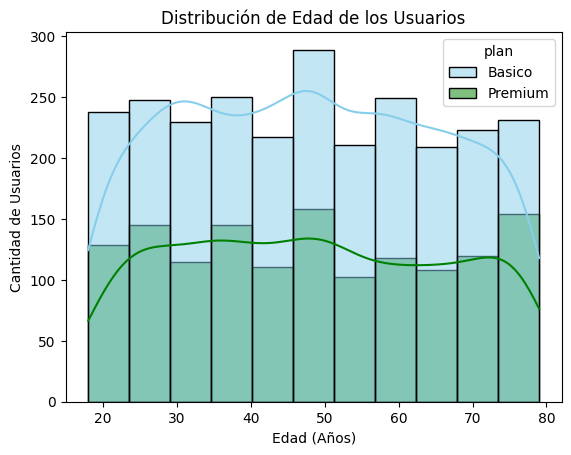

In [44]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', bins=11, palette=['skyblue', 'green'], kde=True)

plt.title('Distribución de Edad de los Usuarios')
plt.xlabel('Edad (Años)')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights:
- La distribución es aproximadamente simétrica y uniforme en ambos planes. No presenta un sesgo marcado hacia la derecha ni hacia la izquierda. Los grupos mas grandes están entre 45 y 50 años. El plan básico presenta proximadamente el doble de usuarios que el plan premium.

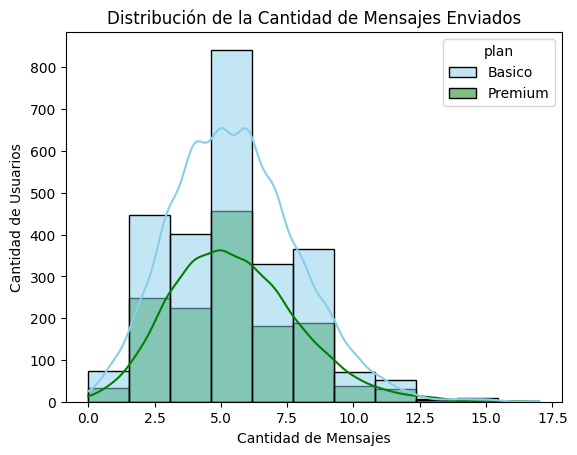

In [45]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=11, palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de la Cantidad de Mensajes Enviados')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights:
- La distribución esta sesgada a la derecha en ambos planes y su comportamiento es practicamente identico. Muestra una forma de campana clara, pero con una cola que se extiende de manera más larga hacia los valores altos. El rango más común se encuentra firmemente entre los 5.0 y 6.0 mensajes, donde se acumulan más de 1,200 usuarios sumando los 2 planes.

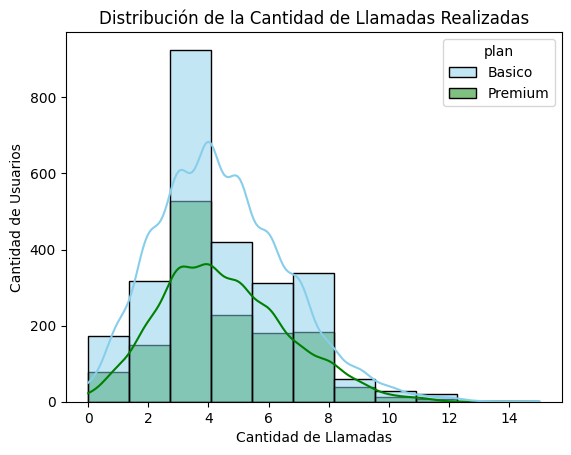

In [46]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=11, palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de la Cantidad de Llamadas Realizadas')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights:
-  La distribución está sesgada a la derecha en ambos planes. Presenta un pico muy marcado al principio y una cola larga que disminuye gradualmente hacia los valores más altos. El pico principal se sitúa firmemente entre las 3 y 4 llamadas, acumulando a más de 1,400 usuarios en ese intervalo sumando los 2 planes.

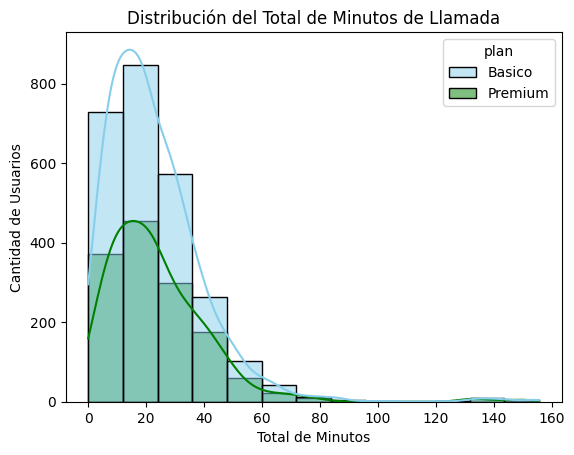

In [47]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=13, palette=['skyblue', 'green'], kde=True)

plt.title('Distribución del Total de Minutos de Llamada')
plt.xlabel('Total de Minutos')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights:
- La distribución está fuertemente sesgada a la derecha en ambos planes. Muestra una acumulación masiva de datos en los valores bajos y una cola muy larga. El pico de la distribución se encuentra firmemente entre los 10 y 20 minutos de llamada, concentrando a casi 1,200 usuarios en ese rango sumando ambos planes.

<div class="alert alert-block alert-danger">
<b>Comentario del Revisor [1° iteración]</b> <a class="tocSkip"></a><br>
<b>A corregir</b>

Los tipos de gráficos y la información general de los mismos es correcta, pero recuerda que en esta actividad el objetivo es comparar las distribuciones de servicios y métricas entre cada **Plan**, es por ello que en las instrucciones te recomiendan hacer uso de **hue='plan' para ver cómo varían las distribuciones según el plan (Básico o Premium).**

Solo deberás agregar estos parámetros a tus funciones de gráficas y con ello lograremos observar las diferencias en cada métricas respecto a ambos planes.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

- **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  


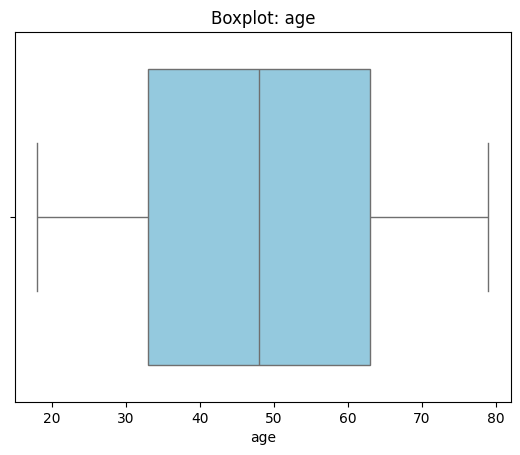

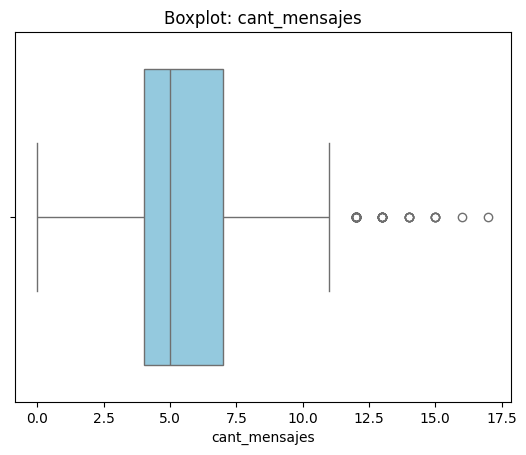

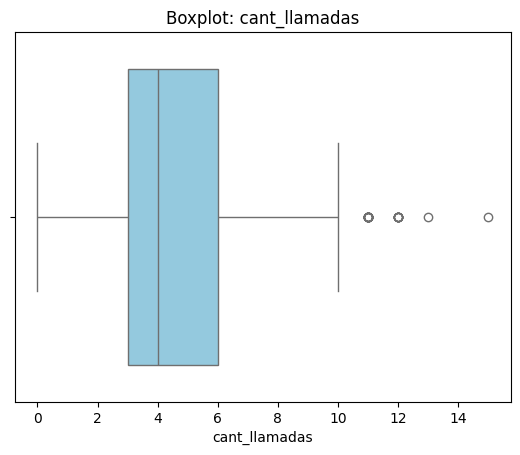

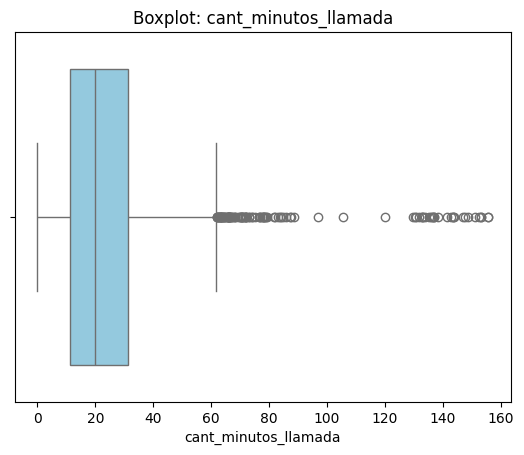

In [50]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights:
- Age: no outliers ni valores imposibles.
- cant_mensajes: Sí presenta outliers del lado derecho. Su tercer cuartil (Q3) está en los 7 mensajes, indicando que el 75% de los usuarios envía un volumen bajo de texto. Los atípicos surgen a partir de los 12 mensajes.
- cant_llamadas: Sí presenta outliers del lado derecho. Su tercer cuartil (Q3) se sitúa en las 6 llamadas, por lo que el 75% de los clientes realiza esa cantidad de llamadas o menos. Los atípicos aparecen a partir de las 11 llamadas.
- cant_minutos_llamada: Sí presenta una cantidad masiva de outliers del lado derecho. Su tercer cuartil (Q3) se encuentra en los 31 minutos, lo que confirma que el 75% de los usuarios habla esa cantidad de tiempo o menos. Los puntos atípicos inician superando los 60 minutos.

In [51]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    # Calcular Q1, Q3 e IQR
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    # Calcular límite superior
    limite_superior = Q3 + 1.5 * IQR

    print(f"Límite Superior para Outliers {col}: {limite_superior}")

Límite Superior para Outliers cant_mensajes: 11.5
Límite Superior para Outliers cant_llamadas: 10.5
Límite Superior para Outliers cant_minutos_llamada: 61.8575


In [52]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡
Insights:
- cant_mensajes: mantener o no outliers, porqué? Se deben mantener los outliers. Aunque el límite matemático es de 11.5 mensajes, el máximo real es de solo 17. Esta pequeña diferencia demuestra que no son errores del sistema.
- cant_llamadas: mantener o no outliers, porqué? El límite superior es de 10.5 y el máximo real alcanza las 15 llamadas. Al igual que con los mensajes, realizar 15 llamadas es un comportamiento perfectamente factible y real dentro de un servicio telefónico.
- cant_minutos_llamada: mantener o no outliers, porqué? Se deben mantener los outliers. A pesar de que el límite matemático es de 61.86 minutos y el máximo real se eleva de forma drástica hasta los 155.69 minutos, este volumen representa a los usuarios de alto consumo del servicio o sería técnicamente viable y recomendable aplicar winsorización para moderar el impacto de estos extremos sin eliminar los registros.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

- Creación de una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.

  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [53]:
# Crear columna grupo_uso
def determinar_segmento(row):
    if row["cant_llamadas"] < 5 and row["cant_mensajes"] < 5:
        return "Bajo uso"
    elif row["cant_llamadas"] < 10 and row["cant_mensajes"] < 10:
        return "Uso medio"
    else:
        return "Alto uso"

# Crear la nueva columna aplicando la función a cada fila
user_profile["grupo_uso"] = user_profile.apply(determinar_segmento, axis=1)

In [54]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Creación de una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.

  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [55]:
# Crear columna grupo_edad
# Función para clasificar clientes por edad
def clasificar_grupo_edad(row):
    edad = row['age']

    # Segmentación por edad
    if edad < 30:
        return "Joven"
    elif edad < 60:
        return "Adulto"
    else:
        return "Adulto Mayor"

# Crear la nueva columna aplicando la función a cada fila
user_profile['grupo_edad'] = user_profile.apply(clasificar_grupo_edad, axis=1)

In [56]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.



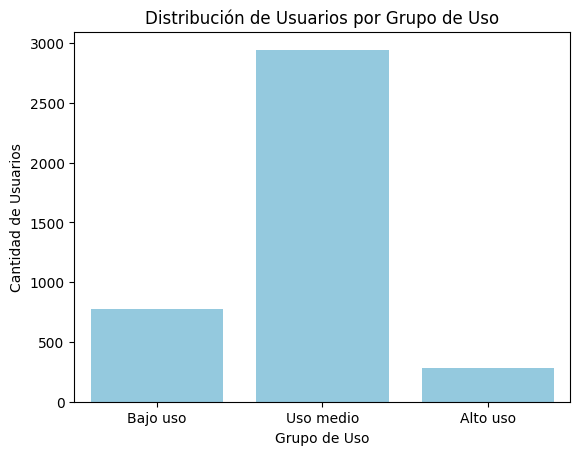

In [57]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', color='skyblue', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

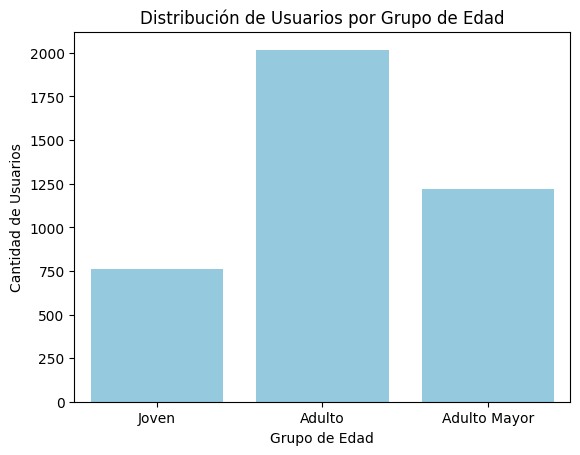

In [58]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', color='skyblue', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.



### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Valores faltantes generales: La columna "city" registró originalmente 469 nulos (11.73%) a los que se sumaron 96 registros que contenían el carácter sentinel "?", consolidando un total de 565 registros faltantes. La columna "date" en consumos presentó 50 nulos (0.13%) críticos que requirieron eliminación.
- Fechas futuras imposibles: Se identificaron 40 usuarios (1.0%) con un año de registro erróneo en reg_date fijado en 2026, los cuales superaban el límite del negocio del año 2024 y fueron corregidos a valores nulos
-  La columna age contenía el valor erróneo -999 como valor mínimo, alterando artificialmente el promedio de edad


🔍 **Segmentos por Edad**
- Predominio del segmento Adulto: La base de clientes está liderada ampliamente por el grupo de Adultos (entre 30 y 59 años), alcanzando un pico masivo de 2,000 usuarios.
- Adultos Mayores en segundo lugar: El segmento de Adultos Mayores (60 años o más) representa una fuerza comercial secundaria muy importante y los Jóvenes (menores de 30 años) constituyen el nicho demográfico más pequeño del dataset.


📊 **Segmentos por Nivel de Uso**
- Concentración en Uso Medio: El comportamiento masivo de la empresa se aloja en el segmento de 'Uso medio'.
- Nicho de Alto consumo: Los clientes de 'Alto uso' representan la minoría más pequeña con aproximadamente 300 usuarios, constituyendo el grupo más intensivo en el uso de infraestructura de red.


➡️ Esto sugiere que la gran masa de clientes de ConnectaTel busca estabilidad y un consumo moderado estandarizado (Uso Medio / Adultos), mientras que existe un grupo muy selecto y reducido de clientes de consumo extremo que requiere atención especializada.


💡 **Recomendaciones**
- Proteger y fidelizar al Segmento VIP (Heavy Users): Mantener intactos en el análisis a los usuarios con patrones extremos en cant_minutos_llamada (quienes superan el límite matemático de 61.86 minutos y llegan hasta los 155.69 minutos). Estos usuarios de alto consumo representan el segmento más rentable y valioso para la empresa; recortarlos con winsorización ocultaría sus necesidades reales de red.
- Creación de un Plan de Bajo Uso: Diseñar un plan de bajo costo enfocado en los 800 usuarios de bajo consumo. Esto permitirá retener a estos clientes evitando que cancelen el servicio por sentir que pagan de más por recursos que no utilizan.
- Implementar validaciones obligatorias en los formularios de registro de la plataforma para impedir la entrada de caracteres inválidos (-999, "?") y fechas imposibles (2026).

Link a repositorio público del proyecto: `LINK a tu repo aquí`

[Miralo en github](https://github.com/axelvazquezp/analysis-ConnectaTel)